# Visualize a Single Run

In [ ]:
# Import the FEMSystem Class from directory above
import sys
sys.path.append('..')
from FEMSystem import FEMSystem

import jax.numpy as jnp
import pickle
import matplotlib.pyplot as plt
import numpy as np
from jax.scipy.sparse.linalg import cg

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

ModuleNotFoundError: No module named 'FEMSystem'

: 

## Get all of the numerical results, and print them

In [ ]:
pickled_obj = {}

with open('./allplots/sweep_sep/sep5/results.pkl', 'rb') as f:
    pickled_obj= pickle.load(f)

femsystem:FEMSystem = pickled_obj["femsystem"]
femsystem.saveFigsDir = None # Turn OFF saving plots
u_even,u_odd = pickled_obj["u_even"],pickled_obj["u_odd"]

# Normalize the modes
u_even = u_even / femsystem.integrate(lambda u,a,b: u**2,u_even)
u_odd = u_odd / femsystem.integrate(lambda u,a,b: u**2,u_odd)

u_even_interior,u_odd_interior = u_even[femsystem.interior_dofs],u_odd[femsystem.interior_dofs]
u_left_interior,u_right_interior = (u_even_interior+u_odd_interior)/jnp.sqrt(2), (u_even_interior-u_odd_interior)/jnp.sqrt(2)
theta_at_dofs = pickled_obj["theta_at_dofs"]
theta_at_interior = theta_at_dofs[femsystem.interior_dofs]
n,coeffs = pickled_obj["n"],pickled_obj["coeffs"]
E_J,E_C,e_0 = pickled_obj["E_J"],pickled_obj["E_C"],pickled_obj["e0"]
parameters = pickled_obj["parameters"]
totalTime = pickled_obj["totalTime"]

material = parameters["material"]
separation = parameters["separation"]
integrated_volume = pickled_obj["integrated_volume"]
sidelenX, sidelenY, sidelenZ = parameters["sidelenX"], parameters["sidelenY"], parameters["sidelenZ"]
volume = 2 * sidelenX * sidelenY * sidelenZ
print(f"Volume Integration Error: {(integrated_volume - volume) / volume * 100:.4g}% | Integrated Volume: {integrated_volume} | Volume: {volume}")

print(f"EJ: {E_J:.4g}, EC: {E_C:.4g}, EJ/EC: {E_J/E_C:.4g} | Time: {int(totalTime // 60)}m {int(totalTime % 60)}s | Degrees of Freedom: {femsystem.dofs}")
print(f"Parameters:")
print(parameters)

def alpha(u,A_int,P_int):
    return 1/(material) * femsystem.double_integral_cg(lambda u1,a,b,c,d: u1**2,lambda u1,a,b,c,d: u1**2,A_int,P_int,u,u)

# Really u*laplacian(u) = -(grad u)^2
def laplacian(u,grad_u,x):
    return -1*jnp.sum(grad_u**2,axis=0)

def epsilon_func(u_global, P_int, phi_theta_int):
    # Kinetic Term
    kinetic = -4 * femsystem.integrate(laplacian,u_global)

    # Potential Term: -2 * <u^2, G theta> = -2 * <u^2, phi_theta>
    u_quad = femsystem._interpolate_values(u_global)
    weighted_u2 = (u_quad**2) * femsystem.weights
    v_u2 = P_int.T @ weighted_u2.ravel()
    potential = -2 * (v_u2 @ phi_theta_int)

    print(f"KE: {kinetic}, PE: {potential}")

    return kinetic  + potential

A_int,P_int = femsystem.get_stiffness_matrix()
# theta_at_quad = femsystem._interpolate_values(theta_at_dofs)
# weighted_theta = theta_at_quad * femsystem.weights
# v_theta = P_int.T @ weighted_theta.ravel()
# phi_theta_int, _ = cg(A_int, v_theta)
# phi_even_int,phi_odd_int = cg(A_int,u_even_interior**2),cg(A_int,u_odd_interior**2)

# alpha_plus,alpha_minus = (alpha(u_even,A_int,P_int),alpha(u_odd,A_int,P_int))
# epsilon_plus,epsilon_minus = epsilon_func(u_even,P_int,phi_theta_int),epsilon_func(u_odd,P_int,phi_theta_int)
# N_val = material * integrated_volume

# print(N_val,epsilon_plus,epsilon_minus,alpha_plus,alpha_minus)
# E_plus,E_minus = epsilon_plus + (N_val-1)*alpha_plus,epsilon_minus + (N_val-1)*alpha_minus
# E_J_calc = ((epsilon_minus - epsilon_plus) + (N_val-1) * (alpha_minus - alpha_plus))/2
# print(E_plus,E_minus)
# print(E_J_calc,E_J)

# def get_opt_objective(n,E_J,E_C,e_0,plot=False):
#     # Copy these three matrix construction functions from 3DTwoModesOpt.py
#     x = (n-1)/2 - jnp.arange(n) # Charge Imbalance Eigenvalue, centered at 0 

#     def Jz2(n):
#         j = (n-1)/2
#         diagonals = j - jnp.arange(n)
#         return jnp.diag(diagonals**2)

#     def off_diag(n,k):
#         ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
#         super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
#         result = super_diag_matrix + sub_diag_matrix
#         return result 

#     def cos_phi(n):
#         return off_diag(n,1) / 2

#     hamiltonian = E_C * Jz2(n) - E_J * cos_phi(n) + e_0 *jnp.eye(n)

#     def expval(mat,vec):
#         return jnp.vdot(vec,mat @ vec)
    
#     return expval(hamiltonian,coeffs)

# print(get_opt_objective(n,E_J,E_C,e_0))

centerLeft,centerRight = ((sidelenX+separation)/2,0,0), (-(sidelenX+separation)/2,0,0)

In [4]:
def theta(x_vec):
    x,y,z = x_vec[0],x_vec[1],x_vec[2]
    cond1 = (jnp.abs(x-centerLeft[0]) <= sidelenX / 2) & (jnp.abs(y-centerLeft[1]) <= sidelenY / 2) & (jnp.abs(z-centerLeft[2]) <= sidelenZ / 2)
    cond2 = (jnp.abs(x-centerRight[0]) <= sidelenX / 2) & (jnp.abs(y-centerRight[1]) <= sidelenY / 2) & (jnp.abs(z-centerRight[2]) <= sidelenZ / 2)
    return cond1 | cond2

def theta_left(x_vec):
    x,y,z= x_vec[0],x_vec[1],x_vec[2]
    cond1 = (jnp.abs(x-centerLeft[0]) <= sidelenX / 2) & (jnp.abs(y-centerLeft[1]) <= sidelenY / 2) & (jnp.abs(z-centerLeft[2]) <= sidelenZ / 2)
    return cond1

def theta_right(x_vec):
    x,y,z = x_vec[0],x_vec[1],x_vec[2]
    cond1 = (jnp.abs(x-centerRight[0]) <= sidelenX / 2) & (jnp.abs(y-centerRight[1]) <= sidelenY / 2) & (jnp.abs(z-centerRight[2]) <= sidelenZ / 2)
    return cond1

def first_func(u,grad_u,u2,grad_u2,x):
        return u
        
def second_func(u,grad_u,u2,grad_u2,x):
    return u2

def potential_integral(u_1,u_2):
    u1_quad = femsystem._interpolate_values(u_1)
    weighted_u1 = u1_quad * femsystem.weights
    v = P_int.T @ weighted_u1.ravel()
    x = femsystem._linear_solve_cg(A_int, v)

    u2_quad = femsystem._interpolate_values(u_2)
    weighted_u2 = (u2_quad) * femsystem.weights
    v_u2 = P_int.T @ weighted_u2.ravel()
    potential = (v_u2 @ x)
    return potential

theta_at_dofs = theta(femsystem.doflocs).astype(jnp.float32)
theta_left_at_dofs = theta_left(femsystem.doflocs).astype(jnp.float32)
theta_right_at_dofs = theta_right(femsystem.doflocs).astype(jnp.float32)
theta_pos = theta_left_at_dofs + theta_right_at_dofs
theta_neg = theta_right_at_dofs - theta_left_at_dofs

total_integral = (potential_integral(theta_neg,theta_neg)) / 4
left_integral = potential_integral(theta_left_at_dofs,theta_right_at_dofs)
right_integral = potential_integral(theta_right_at_dofs,theta_left_at_dofs)
cross_integral = femsystem.double_integral_cg(first_func,second_func,A_int,P_int,theta_left_at_dofs,theta_right_at_dofs) 


odd_modes = (integrated_volume)**2 * (potential_integral(u_odd**2,u_odd**2)) / 4
even_modes = (integrated_volume)**2 * (potential_integral(u_even**2,u_even**2)) / 4

overlap = femsystem.integrate(lambda u,grad_u,x: u,((u_even)**2 - (u_odd)*(u_even))/2)

# Deubgging E_C
computed_ec = 4*potential_integral(u_even*u_odd,u_even*u_odd) / (material**2 * integrated_volume)
approx_ec = 4*potential_integral(theta_neg,theta_neg) / (material**2 * integrated_volume**3)
print(f"Approx E_C: {approx_ec} | True E_C: {E_C}")

print(f"Cross Integral: {cross_integral}")
print(f"Left Integral: {left_integral}")
print(f"Right Integral: {right_integral}")
print(f"Total Integral: {total_integral}")
print(f"Modes Squared Integral, Odd: {odd_modes} Even: {even_modes}")

Approx E_C: 0.056885749101638794 | True E_C: 0.05077730491757393
Cross Integral: 874.249755859375
Left Integral: 874.2500610351562
Right Integral: 874.2495727539062
Total Integral: 4254.02734375
Modes Squared Integral, Odd: 4814.33544921875 Even: 4606.07080078125


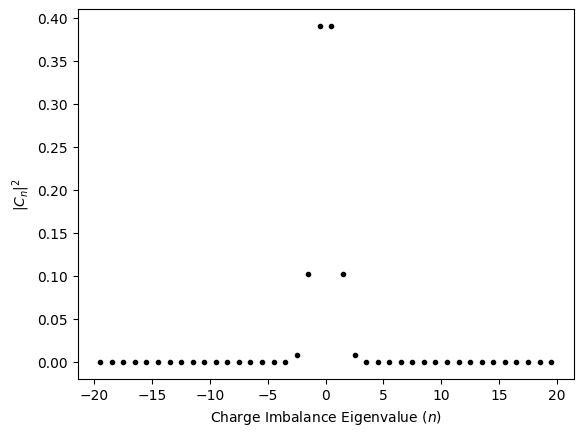

In [3]:
# Plot the coefficients of the eigenvectors, only the middle m
m = 20
x = (n-1)/2 - jnp.arange(n)

#normalize the coefficients
coeffs = (coeffs / jnp.sqrt(jnp.sum(coeffs**2)))**2

plt.plot(x[n//2-m:n//2+m],coeffs[n//2-m:n//2+m],".",color="black")
plt.xlabel(r"Charge Imbalance Eigenvalue ($n$)")
plt.ylabel(r"$|C_n|^2$")
plt.show()

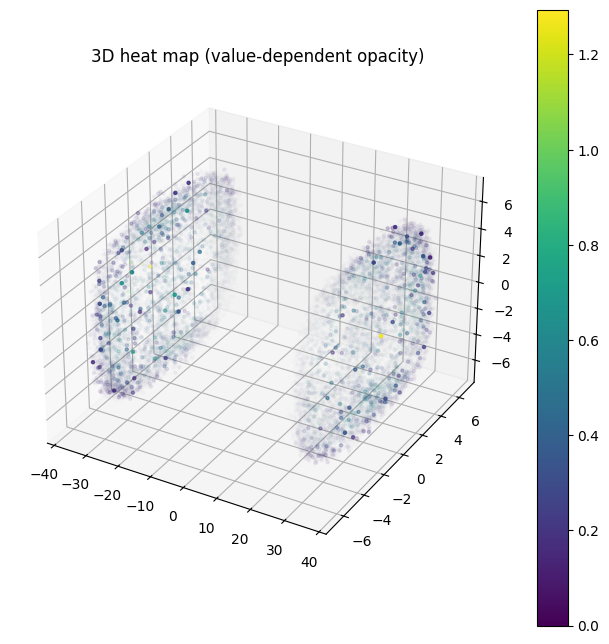

(<Figure size 800x800 with 2 Axes>,
 <Axes3D: title={'center': '3D heat map (value-dependent opacity)'}>,
 <mpl_toolkits.mplot3d.art3d.Path3DCollection at 0x1522b41981c0>)

In [4]:
theta_pos_interior = theta_pos[femsystem.interior_dofs]
femsystem.plot_interior_at_quad_3d_heatmap(integrated_volume*(u_even_interior**2))

In [5]:
# Time Breakdown

times = pickled_obj["times"]
mesh_gen_time,mesh_load_time,matrix_gen_time,objective_run_time,optimization_loop_time = times["mesh_gen"],times["mesh_load"],times["matrix_gen"],times["objective_run"],times["optimization_loop"]
print(f"Time Breakdown:")
print(f"  - Mesh Generation: {mesh_gen_time:.4g}s | {mesh_gen_time/totalTime*100:.4g}%")
print(f"  - Mesh Loading: {mesh_load_time:.4g}s | {mesh_load_time/totalTime*100:.4g}%")
print(f"  - Matrix Generation: {matrix_gen_time:.4g}s | {matrix_gen_time/totalTime*100:.4g}%")
print(f"  - Objective Run: {objective_run_time:.4g}s | {objective_run_time/totalTime*100:.4g}%")
print(f"  - Optimization Loop: {optimization_loop_time:.4g}s | {optimization_loop_time/totalTime*100:.4g}%")
print(f"  - Total: {totalTime:.4g}s")

Time Breakdown:
  - Mesh Generation: 29.16s | 2.027%
  - Mesh Loading: 35.56s | 2.471%
  - Matrix Generation: 5.403s | 0.3755%
  - Objective Run: 55.37s | 3.848%
  - Optimization Loop: 1324s | 92%
  - Total: 1439s


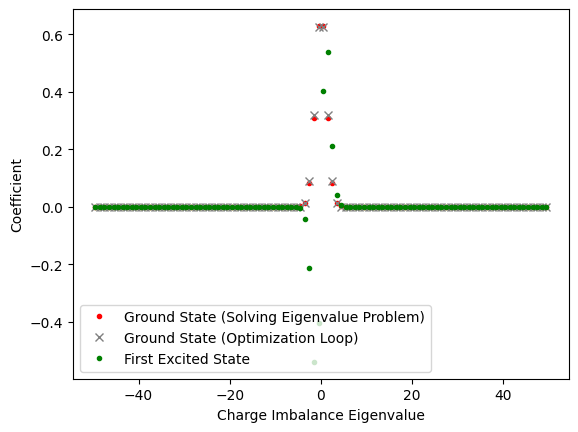

Matrix Element <e|n|g>: 0.8485


In [4]:
# Create the Hamiltonian Operator over Truncated Basis, to find eigenvectors for first excited state


def get_spontaneous_emission_matrix_element(n,E_J,E_C,plot=False):
    # Copy these three matrix construction functions from 3DTwoModesOpt.py
    x = (n-1)/2 - jnp.arange(n) # Charge Imbalance Eigenvalue, centered at 0 

    def Jz2(n):
        j = (n-1)/2
        diagonals = j - jnp.arange(n)
        return jnp.diag(diagonals**2)

    def off_diag(n,k):
        ones_super, ones_sub = jnp.ones(n - k, dtype=jnp.int32),jnp.ones(n - k, dtype=jnp.int32)
        super_diag_matrix,sub_diag_matrix= jnp.diag(ones_super, k=k),jnp.diag(ones_sub, k=-1*k)
        result = super_diag_matrix + sub_diag_matrix
        return result 

    def cos_phi(n):
        return off_diag(n,1) / 2

    hamiltonian = E_C * Jz2(n) - E_J * cos_phi(n) # No need for e_0 term, since we are only interested in eigenvectors

    # Find Eigenvalues and Eigenvectors
    eigenvalues,eigenvectors = jnp.linalg.eigh(hamiltonian)

    # Plot the ground state, first eigenvector
    ground_state_coeffs_from_optimization = coeffs / jnp.sqrt(jnp.sum(coeffs**2))
    ground_state_coeffs = eigenvectors[:,0] / jnp.sqrt(jnp.sum(eigenvectors[:,0]**2))
    first_excited_coeffs = eigenvectors[:,1] / jnp.sqrt(jnp.sum(eigenvectors[:,1]**2))

    if plot: 
        plt.plot(x,ground_state_coeffs,".",color="red",label="Ground State (Solving Eigenvalue Problem)")
        plt.plot(x,ground_state_coeffs_from_optimization,"x",color="grey",label="Ground State (Optimization Loop)")
        plt.plot(x,first_excited_coeffs,".",color="green",label="First Excited State")
        plt.xlabel("Charge Imbalance Eigenvalue")
        plt.ylabel("Coefficient")
        plt.legend()
        plt.show()

    return jnp.sum(first_excited_coeffs * ground_state_coeffs * x) # x is the charge imbalance eigenvalue

matrix_element_eg = get_spontaneous_emission_matrix_element(n,E_J,E_C,plot=True)
print(f"Matrix Element <e|n|g>: {matrix_element_eg:.4g}")

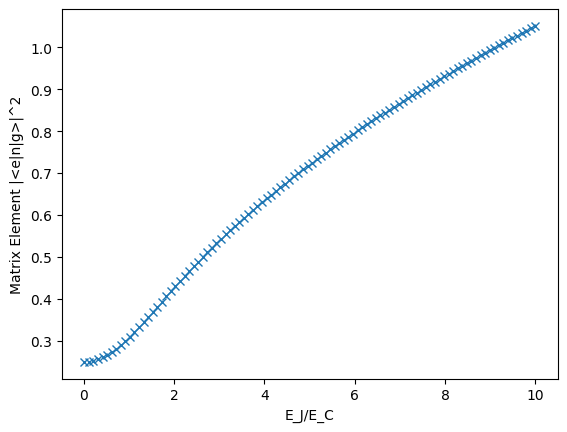

In [5]:
# Plot how matrix element changes with varying E_J, E_C, e_0

sweep_vals = jnp.linspace(0.01,10,100) # EJ/EC ratios, assuming EC = 1
mat_element_sweep = jnp.array([get_spontaneous_emission_matrix_element(n,E_J*10,10,plot=False) for E_J in sweep_vals])

plt.plot(sweep_vals,mat_element_sweep**2,"x")
plt.xlabel("E_J/E_C")
plt.ylabel("Matrix Element |<e|n|g>|^2")
plt.show()

# Remember, if we bring islands further apart, we expect EJ/EC to go down. So as we bring islands further, matrix element should go down, and separtion to go up. 

## Plot the Odd Mode, in Slices

## Plot the Odd Mode as a single 3D heat map (value-dependent opacity)

Same data as the slice plot, but in one figure: **high values are drawn opaque and low values transparent**, so you can see the 3D function shape at a glance without slices. 

**Key features:**
- **Auto-filters low values**: Points below 10% of max absolute value are removed entirely (prevents accumulation of many transparent points that still appear opaque)
- Low values → fully transparent (alpha=0.0) so they don't block the view
- High values → fully opaque (alpha=1.0) so they stand out clearly
- Uses aggressive power-law mapping (power=4) so low values fade very quickly
- Automatically subsamples if too many points (max_points=50000)
- Optional: `value_threshold` to override auto-filtering (e.g., `value_threshold=0.001`)

(<Figure size 800x800 with 2 Axes>,
 <Axes3D: title={'center': 'Left Mode'}>,
 <mpl_toolkits.mplot3d.art3d.Path3DCollection at 0x145a900e2d60>)

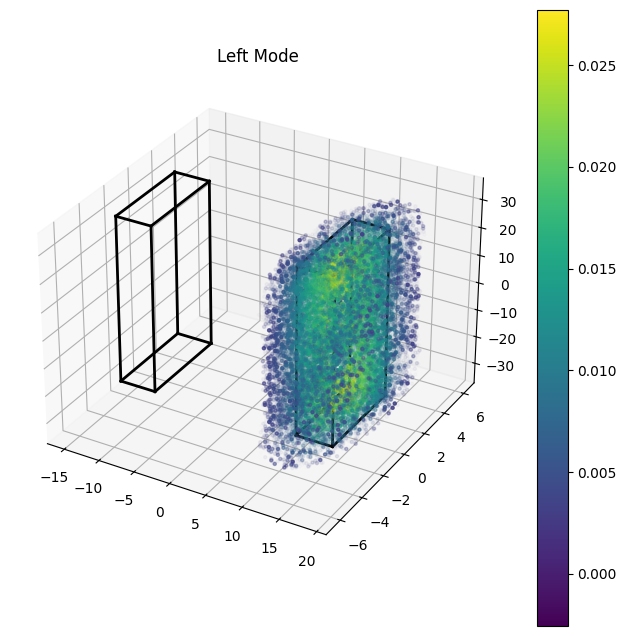

In [4]:
# Single-plot 3D heat map: high values opaque, low values transparent (no slices)
# Auto-filters points below 10% of max absolute value to prevent purple dots from accumulating
# Optional: adjust opacity_power (default 4, higher = more aggressive fade) or value_threshold
femsystem.plot_interior_at_quad_3d_heatmap(u_left_interior, plot_title="Left Mode", max_points=50000,value_threshold=0.003,    
    prism_centers=[centerLeft,centerRight],
    prism_side_lengths=[(sidelenX, sidelenY, sidelenZ),(sidelenX, sidelenY, sidelenZ)],
    wire_color="black",
    wire_linewidth=2.0
)

(<Figure size 800x800 with 2 Axes>,
 <Axes3D: title={'center': 'Right Mode'}>,
 <mpl_toolkits.mplot3d.art3d.Path3DCollection at 0x14598c07d910>)

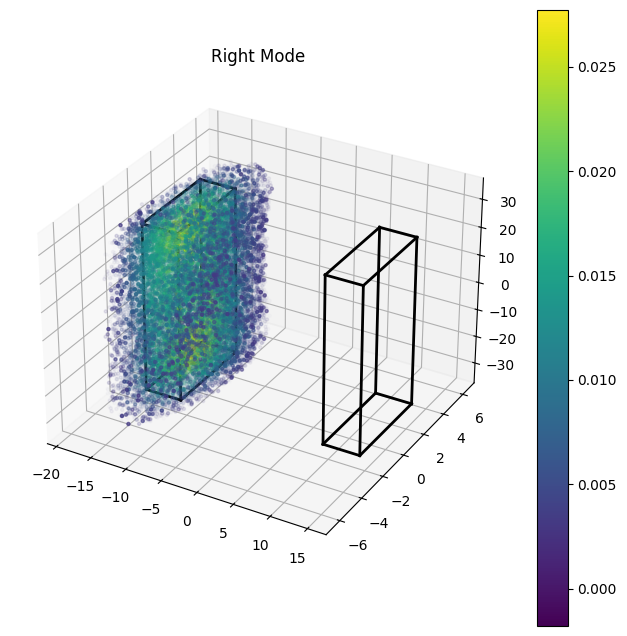

: 

In [ ]:
# Single-plot 3D heat map: high values opaque, low values transparent (no slices)
# Auto-filters points below 10% of max absolute value to prevent purple dots from accumulating
# Optional: adjust opacity_power (default 4, higher = more aggressive fade) or value_threshold
femsystem.plot_interior_at_quad_3d_heatmap(u_right_interior, plot_title="Right Mode", max_points=50000,value_threshold=0.003,    
    prism_centers=[centerLeft,centerRight],
    prism_side_lengths=[(sidelenX, sidelenY, sidelenZ),(sidelenX, sidelenY, sidelenZ)],
    wire_color="black",
    wire_linewidth=2.0
)

V min to max: -0.0023130598 0.035566576


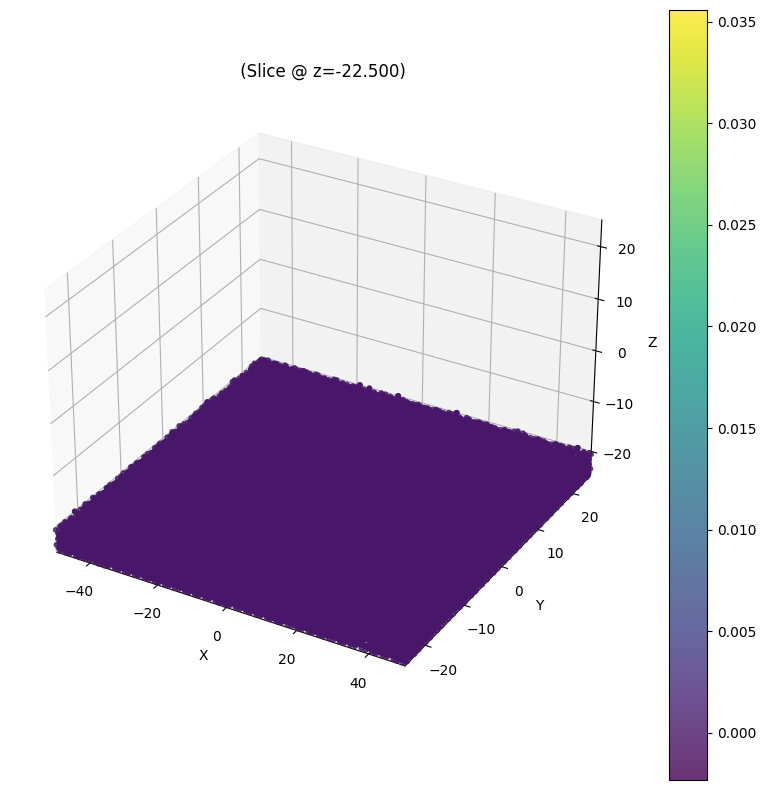

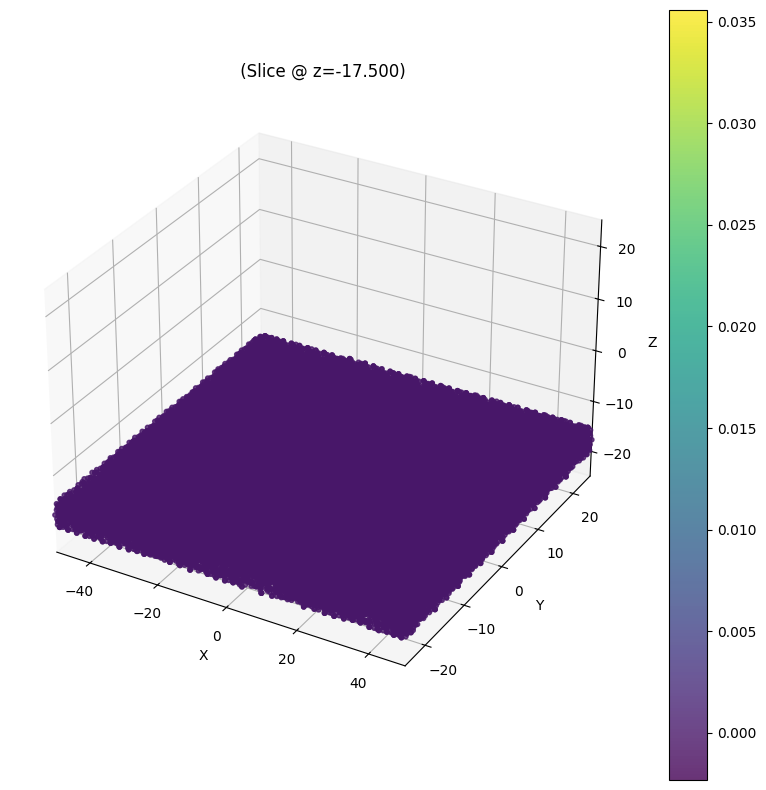

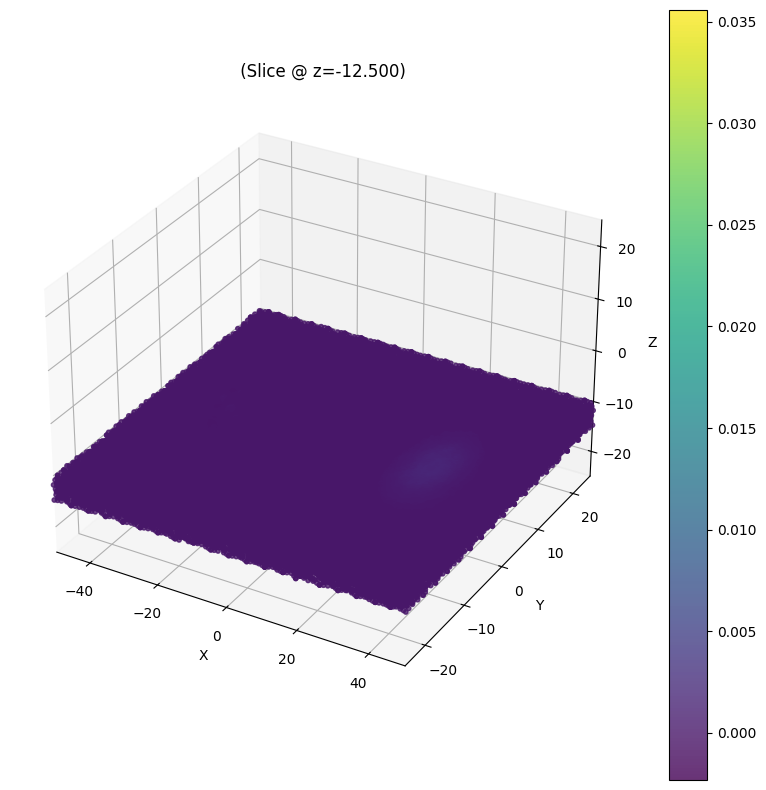

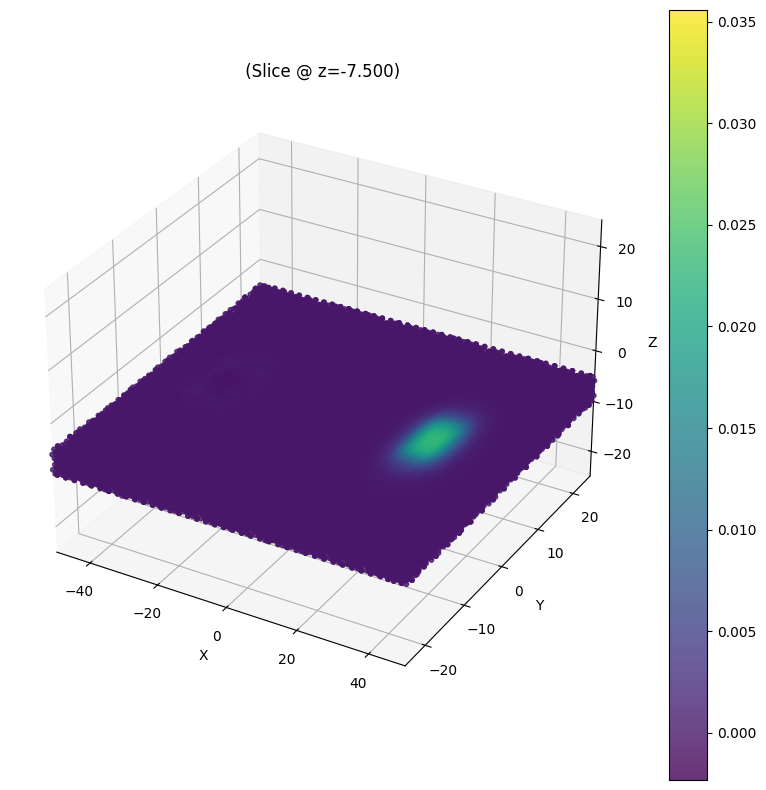

: 

In [8]:
femsystem.plot_n_slices_interior(u_left_interior,n_slices=10)

## Plot the Even Mode, in Slices

In [5]:
# Take inverse of A_int, first convert to dense matrix
A_int_dense = A_int.todense()
A_inv = jnp.linalg.inv(A_int_dense)

femsystem.plot_n_slices_interior(A_inv[:,0],n_slices=10)

2026-02-19 16:30:48.839598: W external/xla/xla/service/hlo_rematerialization.cc:3005] Can't reduce memory use below -58.60GiB (-62918237226 bytes) by rematerialization; only reduced to 91.30GiB (98034114816 bytes), down from 91.30GiB (98034114816 bytes) originally
2026-02-19 16:30:58.878218: W external/xla/xla/tsl/framework/bfc_allocator.cc:482] Allocator (GPU_0_bfc) ran out of memory trying to allocate 91.30GiB (rounded to 98034114816)requested by op 
2026-02-19 16:30:58.878432: W external/xla/xla/tsl/framework/bfc_allocator.cc:494] ______________***************________________________________________*******************************
E0219 16:30:58.878462 1494937 pjrt_stream_executor_client.cc:2985] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 98034114816 bytes.


XlaRuntimeError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 98034114816 bytes.

## Plot the Geometry, in Slices

In [ ]:
femsystem.plot_n_slices_interior(theta_at_interior,n_slices=10)